In [3]:
import torch

| Parameter                    | What It Controls                                                         | Typical Range      | Effect                                   |
| ---------------------------- | ------------------------------------------------------------------------ | ------------------ | ---------------------------------------- |
| **Temperature**              | Randomness of token selection                                            | 0 – 2              | Lower = deterministic, Higher = creative |
| **Top-K**                    | Limits selection to K highest probability tokens                         | 1 – 100            | Removes unlikely tokens                  |
| **Top-P (Nucleus Sampling)** | Chooses tokens until cumulative probability reaches P                    | 0.8 – 0.95         | Dynamic alternative to Top-K             |
| **Max Tokens**               | Maximum tokens the model generates                                       | Depends on model   | Controls response length                 |
| **Frequency Penalty**        | Penalizes tokens that appear frequently                                  | 0 – 2              | Reduces repetition                       |
| **Presence Penalty**         | Penalizes tokens that appeared at least once                             | 0 – 2              | Encourages new topics                    |
| **Repeat Penalty**           | Penalizes repeated tokens during generation                              | 1 – 2              | Prevents loops like “hello hello”        |
| **Typical-P**                | Filters tokens based on typical probability distribution                 | 0.8 – 1            | Removes outlier tokens                   |
| **Min-P**                    | Keeps tokens above a probability threshold relative to the highest token | 0 – 1              | Filters very unlikely tokens             |
| **TFS (tfs_z)**              | Tail Free Sampling control                                               | 0.5 – 1            | Removes low-probability tail tokens      |
| **Beam Search**              | Explores multiple best sequences simultaneously                          | 2 – 10 beams       | More optimal but slower                  |
| **Greedy Decoding**          | Always selects highest probability token                                 | N/A                | Most deterministic                       |
| **Mirostat**                 | Adaptive sampling to control perplexity                                  | mode 1 or 2        | Maintains stable generation quality      |
| **Stop Sequences**           | Tokens or strings that stop generation                                   | Custom strings     | Ends output when encountered             |
| **Seed**                     | Random seed for reproducible outputs                                     | Any integer        | Same input → same output                 |
| **Context Length**           | Maximum tokens model can read in prompt                                  | 4K – 200K+         | Determines input size                    |
| **Batch Size**               | Number of tokens processed together                                      | Hardware dependent | Affects inference speed                  |


In [1]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

## **Temparature Scailing**

In [4]:
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

next_token_logits2 = next_token_logits/0.1

next_token_logits3 = next_token_logits/5

In [5]:
probas = torch.softmax(next_token_logits2, dim=0)

print(probas)

tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])


In [6]:
probas = torch.softmax(next_token_logits, dim=0)

print(probas)

next_token_id = torch.argmax(probas).item()

print(next_token_id)

print(inverse_vocab[next_token_id])

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
3
forward


In [15]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

toward


In [19]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you


In [9]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

##Multinomial

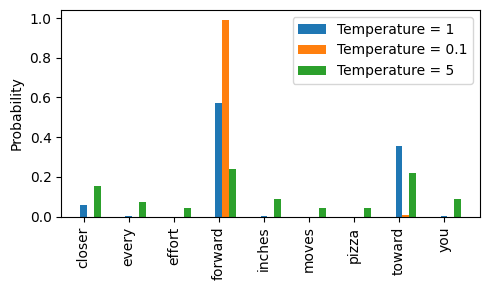

In [11]:
import matplotlib.pyplot as plt
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

## **Top-k Sampling**

In [20]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [22]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [23]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [24]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx